## Imports

In [1]:
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import resnet18

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.constants import EMOTION_LABELS, NUM_CLASSES
from src.dataset import FER2013Dataset
from src.train_utils import get_device, set_seed

## Configuration

In [2]:
CSV_PATH = PROJECT_ROOT / "data/raw/fer2013/fer2013.csv"

CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"
IMAGES_DIR = PROJECT_ROOT / "images"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT_PATH = (
    CHECKPOINTS_DIR
    / "run_25_resnet18_full_aug_scheduler_best.pt"
)

WANDB_ENTITY = "lkhiz23-free-university-of-tbilisi-"
WANDB_PROJECT = "facial-expression-recognition"
WANDB_RUN_NAME = "run_26_resnet18_private_test"

TRAIN_MEAN = 0.5077426
TRAIN_STD = 0.25500894

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

RESNET_IMAGE_SIZE = 224
BATCH_SIZE = 4

set_seed(42)
device = get_device()

print("Device:", device)
print("Checkpoint:", BEST_CHECKPOINT_PATH.resolve())
print("Checkpoint exists:", BEST_CHECKPOINT_PATH.exists())

if not BEST_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint was not found: {BEST_CHECKPOINT_PATH}"
    )

Device: cuda
Checkpoint: /home/xizusha/Documents/ML/Facial-Expression-Recognition/checkpoints/run_25_resnet18_full_aug_scheduler_best.pt
Checkpoint exists: True


## PrivateTest Preprocessing

In [4]:
class ResNetFER2013TestDataset(Dataset):
    def __init__(self, csv_path, split):
        self.base_dataset = FER2013Dataset(
            csv_path,
            split=split,
            transform=None,
        )

        self.resize = transforms.Resize(
            (RESNET_IMAGE_SIZE, RESNET_IMAGE_SIZE),
            antialias=True,
        )

        self.imagenet_normalize = transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        )

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        image, label = self.base_dataset[index]

        # Undo FER2013 normalization.
        image = image * TRAIN_STD + TRAIN_MEAN
        image = image.clamp(0.0, 1.0)

        image = self.resize(image)

        # Convert one grayscale channel into three channels.
        image = image.repeat(3, 1, 1)

        image = self.imagenet_normalize(image)

        return image, label

## Load PrivateTest Dataset

In [5]:
private_test_dataset = ResNetFER2013TestDataset(
    CSV_PATH,
    split="PrivateTest",
)

private_test_loader = DataLoader(
    private_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

sample_image, sample_label = private_test_dataset[0]

print("PrivateTest samples:", len(private_test_dataset))
print("Input shape:", sample_image.shape)
print("Label:", sample_label.item())

PrivateTest samples: 3589
Input shape: torch.Size([3, 224, 224])
Label: 0


## Recreate the Selected ResNet18 Architecture

In [6]:
def build_final_resnet18(dropout=0.3):
    model = resnet18(weights=None)

    classifier_input_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(
            classifier_input_features,
            NUM_CLASSES,
        ),
    )

    return model

## Load the Best Checkpoint

In [7]:
final_model = build_final_resnet18(
    dropout=0.3,
).to(device)

try:
    best_state_dict = torch.load(
        BEST_CHECKPOINT_PATH,
        map_location=device,
        weights_only=True,
    )
except TypeError:
    best_state_dict = torch.load(
        BEST_CHECKPOINT_PATH,
        map_location=device,
    )

final_model.load_state_dict(best_state_dict)
final_model.eval()

print("Best ResNet18 checkpoint loaded successfully.")

Best ResNet18 checkpoint loaded successfully.


## Evaluation Function

In [10]:
def evaluate_final_model(
    model,
    loader,
    criterion,
    device,
):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_predictions = []

    device_type = (
        device.type
        if isinstance(device, torch.device)
        else str(device).split(":")[0]
    )

    use_amp = device_type == "cuda"

    with torch.inference_mode():
        for batch_index, (images, labels) in enumerate(
            loader,
            start=1,
        ):
            images = images.to(device)
            labels = labels.to(device)

            with torch.autocast(
                device_type=device_type,
                dtype=torch.float16,
                enabled=use_amp,
            ):
                outputs = model(images)
                loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            all_labels.extend(
                labels.cpu().tolist()
            )

            all_predictions.extend(
                predictions.cpu().tolist()
            )

            if batch_index % 50 == 0:
                processed = min(
                    batch_index * loader.batch_size,
                    len(loader.dataset),
                )

                print(
                    f"Processed {processed}/"
                    f"{len(loader.dataset)} images",
                    flush=True,
                )

    average_loss = total_loss / len(loader.dataset)

    accuracy = accuracy_score(
        all_labels,
        all_predictions,
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )

    return {
        "loss": average_loss,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "labels": all_labels,
        "predictions": all_predictions,
    }

## Evaluate the Final Model on PrivateTest

In [11]:
criterion = nn.CrossEntropyLoss()

private_test_results = evaluate_final_model(
    final_model,
    private_test_loader,
    criterion,
    device,
)

private_test_loss = private_test_results["loss"]
private_test_accuracy = private_test_results["accuracy"]
private_test_macro_f1 = private_test_results["macro_f1"]

private_test_labels = private_test_results["labels"]
private_test_predictions = (
    private_test_results["predictions"]
)

print(
    f"PrivateTest Loss: "
    f"{private_test_loss:.5f}"
)

print(
    f"PrivateTest Accuracy: "
    f"{private_test_accuracy:.5f}"
)

print(
    f"PrivateTest Macro F1: "
    f"{private_test_macro_f1:.5f}"
)

Processed 200/3589 images
Processed 400/3589 images
Processed 600/3589 images
Processed 800/3589 images
Processed 1000/3589 images
Processed 1200/3589 images
Processed 1400/3589 images
Processed 1600/3589 images
Processed 1800/3589 images
Processed 2000/3589 images
Processed 2200/3589 images
Processed 2400/3589 images
Processed 2600/3589 images
Processed 2800/3589 images
Processed 3000/3589 images
Processed 3200/3589 images
Processed 3400/3589 images
PrivateTest Loss: 0.99343
PrivateTest Accuracy: 0.71106
PrivateTest Macro F1: 0.70811


## Per-Class Classification Report

In [12]:
class_names = [
    EMOTION_LABELS[index]
    for index in range(NUM_CLASSES)
]

label_indices = list(range(NUM_CLASSES))

private_test_report = classification_report(
    private_test_labels,
    private_test_predictions,
    labels=label_indices,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

private_test_report_df = (
    pd.DataFrame(private_test_report)
    .transpose()
)

private_test_report_df

,precision,recall,f1-score,support
Angry,0.650862,0.615071,0.632461,491.000000
Disgust,0.833333,0.727273,0.776699,55.000000
Fear,0.594705,0.553030,0.573111,528.000000
Happy,0.901826,0.898749,0.900285,879.000000
Sad,0.531298,0.585859,0.557246,594.000000
Surprise,0.835381,0.817308,0.826245,416.000000
Neutral,0.679012,0.702875,0.690738,626.000000
accuracy,0.711062,0.711062,0.711062,0.711062
macro avg,0.718060,0.700024,0.708112,3589.000000
weighted avg,0.713371,0.711062,0.711712,3589.000000


## Confusion Matrix

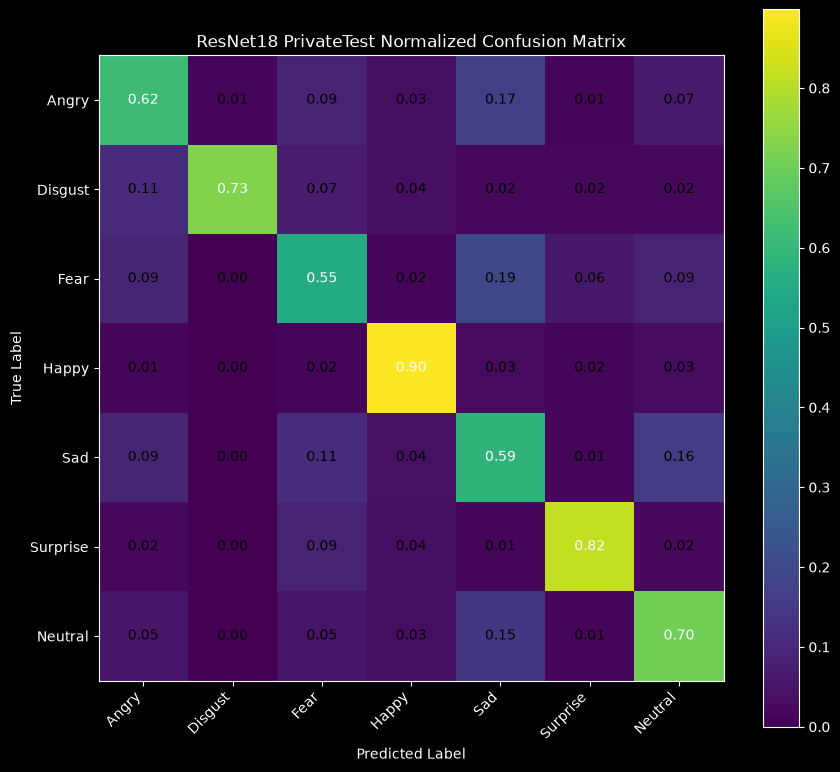

Confusion matrix saved to: /home/xizusha/Documents/ML/Facial-Expression-Recognition/images/resnet18_private_test_confusion_matrix.png


In [13]:
private_test_confusion_matrix = confusion_matrix(
    private_test_labels,
    private_test_predictions,
    labels=label_indices,
)

row_sums = private_test_confusion_matrix.sum(
    axis=1,
    keepdims=True,
)

normalized_confusion_matrix = np.divide(
    private_test_confusion_matrix,
    row_sums,
    out=np.zeros_like(
        private_test_confusion_matrix,
        dtype=float,
    ),
    where=row_sums != 0,
)

plt.figure(figsize=(9, 8))

matrix_image = plt.imshow(
    normalized_confusion_matrix,
    interpolation="nearest",
)

plt.colorbar(matrix_image)

tick_positions = np.arange(NUM_CLASSES)

plt.xticks(
    tick_positions,
    class_names,
    rotation=45,
    ha="right",
)

plt.yticks(
    tick_positions,
    class_names,
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(
    "ResNet18 PrivateTest Normalized Confusion Matrix"
)

threshold = normalized_confusion_matrix.max() / 2

for row_index in range(NUM_CLASSES):
    for column_index in range(NUM_CLASSES):
        value = normalized_confusion_matrix[
            row_index,
            column_index,
        ]

        plt.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=(
                "white"
                if value > threshold
                else "black"
            ),
        )

plt.tight_layout()

CONFUSION_MATRIX_IMAGE_PATH = (
    IMAGES_DIR
    / "resnet18_private_test_confusion_matrix.png"
)

plt.savefig(
    CONFUSION_MATRIX_IMAGE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()
plt.close()

print(
    "Confusion matrix saved to:",
    CONFUSION_MATRIX_IMAGE_PATH,
)

## Save Final Results Locally

In [14]:
FINAL_METRICS_PATH = (
    RESULTS_DIR
    / "resnet18_private_test_metrics.json"
)

CLASSIFICATION_REPORT_PATH = (
    RESULTS_DIR
    / "resnet18_private_test_classification_report.csv"
)

CONFUSION_MATRIX_CSV_PATH = (
    RESULTS_DIR
    / "resnet18_private_test_confusion_matrix.csv"
)

final_metrics = {
    "model": "ResNet18",
    "selected_training_run":
        "run_25_resnet18_full_aug_scheduler",
    "selected_checkpoint_epoch": 18,
    "checkpoint_selection_metric":
        "validation_accuracy",
    "best_validation_accuracy": 0.691836,
    "best_validation_macro_f1": 0.684620,
    "private_test_loss":
        float(private_test_loss),
    "private_test_accuracy":
        float(private_test_accuracy),
    "private_test_macro_f1":
        float(private_test_macro_f1),
    "private_test_samples":
        len(private_test_dataset),
}

with FINAL_METRICS_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        final_metrics,
        file,
        indent=2,
    )

private_test_report_df.to_csv(
    CLASSIFICATION_REPORT_PATH,
)

pd.DataFrame(
    private_test_confusion_matrix,
    index=class_names,
    columns=class_names,
).to_csv(
    CONFUSION_MATRIX_CSV_PATH,
)

print("Saved:", FINAL_METRICS_PATH)
print("Saved:", CLASSIFICATION_REPORT_PATH)
print("Saved:", CONFUSION_MATRIX_CSV_PATH)

Saved: /home/xizusha/Documents/ML/Facial-Expression-Recognition/results/resnet18_private_test_metrics.json
Saved: /home/xizusha/Documents/ML/Facial-Expression-Recognition/results/resnet18_private_test_classification_report.csv
Saved: /home/xizusha/Documents/ML/Facial-Expression-Recognition/results/resnet18_private_test_confusion_matrix.csv


## Log Final Evaluation to W&B

In [15]:
final_test_run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name=WANDB_RUN_NAME,
    job_type="final_evaluation",
    config={
        "model": "ResNet18",
        "selected_training_run":
            "run_25_resnet18_full_aug_scheduler",
        "selected_checkpoint_epoch": 18,
        "checkpoint_selection_metric":
            "validation_accuracy",
        "best_validation_accuracy": 0.691836,
        "best_validation_macro_f1": 0.684620,
        "test_split": "PrivateTest",
        "fine_tune_strategy": "full",
        "augmentation_during_training": "light",
        "augmentation_during_test": "none",
        "dropout": 0.3,
        "weight_decay": 1e-4,
        "input_shape": "3x224x224",
        "private_test_samples":
            len(private_test_dataset),
    },
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/xizusha/.netrc.
wandb: Currently logged in as: lkhiz23 (lkhiz23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [16]:
final_test_run.log({
    "private_test_loss":
        private_test_loss,
    "private_test_accuracy":
        private_test_accuracy,
    "private_test_macro_f1":
        private_test_macro_f1,
})

In [17]:
final_test_run.log({
    "private_test_confusion_matrix":
        wandb.plot.confusion_matrix(
            y_true=private_test_labels,
            preds=private_test_predictions,
            class_names=class_names,
        )
})

## Log Per-Class Metrics

In [18]:
per_class_table = wandb.Table(
    columns=[
        "class",
        "precision",
        "recall",
        "f1_score",
        "support",
    ]
)

for class_name in class_names:
    class_metrics = private_test_report[
        class_name
    ]

    per_class_table.add_data(
        class_name,
        class_metrics["precision"],
        class_metrics["recall"],
        class_metrics["f1-score"],
        class_metrics["support"],
    )

final_test_run.log({
    "private_test_per_class_metrics":
        per_class_table
})

## Log the Final Model as a W&B Artifact

In [19]:
model_artifact = wandb.Artifact(
    name="resnet18-fer2013-best",
    type="model",
    description=(
        "Best ResNet18 checkpoint selected using "
        "PublicTest validation accuracy and evaluated "
        "once on PrivateTest."
    ),
    metadata={
        "source_training_run":
            "run_25_resnet18_full_aug_scheduler",
        "best_epoch": 18,
        "best_validation_accuracy": 0.691836,
        "best_validation_macro_f1": 0.684620,
        "private_test_accuracy":
            float(private_test_accuracy),
        "private_test_macro_f1":
            float(private_test_macro_f1),
    },
)

model_artifact.add_file(
    str(BEST_CHECKPOINT_PATH)
)

final_test_run.log_artifact(
    model_artifact
)

<Artifact resnet18-fer2013-best>

In [20]:
final_test_run.summary[
    "private_test_loss"
] = private_test_loss

final_test_run.summary[
    "private_test_accuracy"
] = private_test_accuracy

final_test_run.summary[
    "private_test_macro_f1"
] = private_test_macro_f1

final_test_run.summary[
    "selected_checkpoint_epoch"
] = 18

final_test_run.finish()

print(
    "Final PrivateTest evaluation and model artifact "
    "were logged successfully."
)

private_test_accuracy,▁
private_test_loss,▁
private_test_macro_f1,▁
private_test_accuracy,0.71106
private_test_loss,0.99343
private_test_macro_f1,0.70811
selected_checkpoint_epoch,18


Final PrivateTest evaluation and model artifact were logged successfully.
